<a href="https://colab.research.google.com/github/sap-tarshi-ghosh/Image-Processing-Tutorial/blob/main/code/channel_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image Color Space Visualization

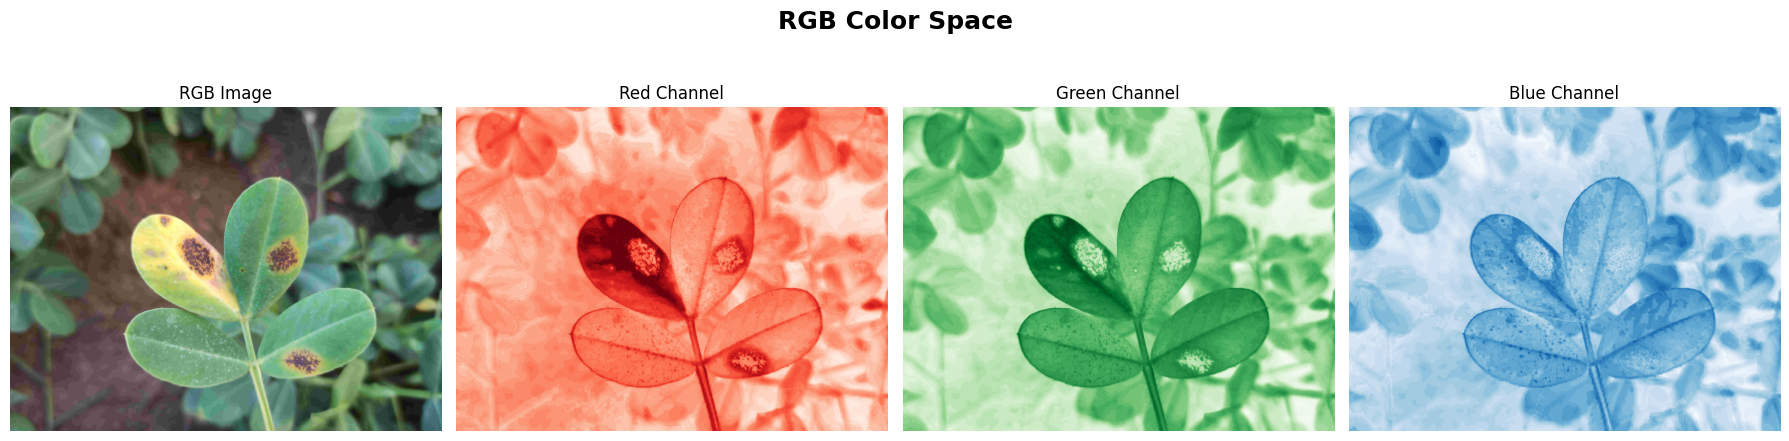

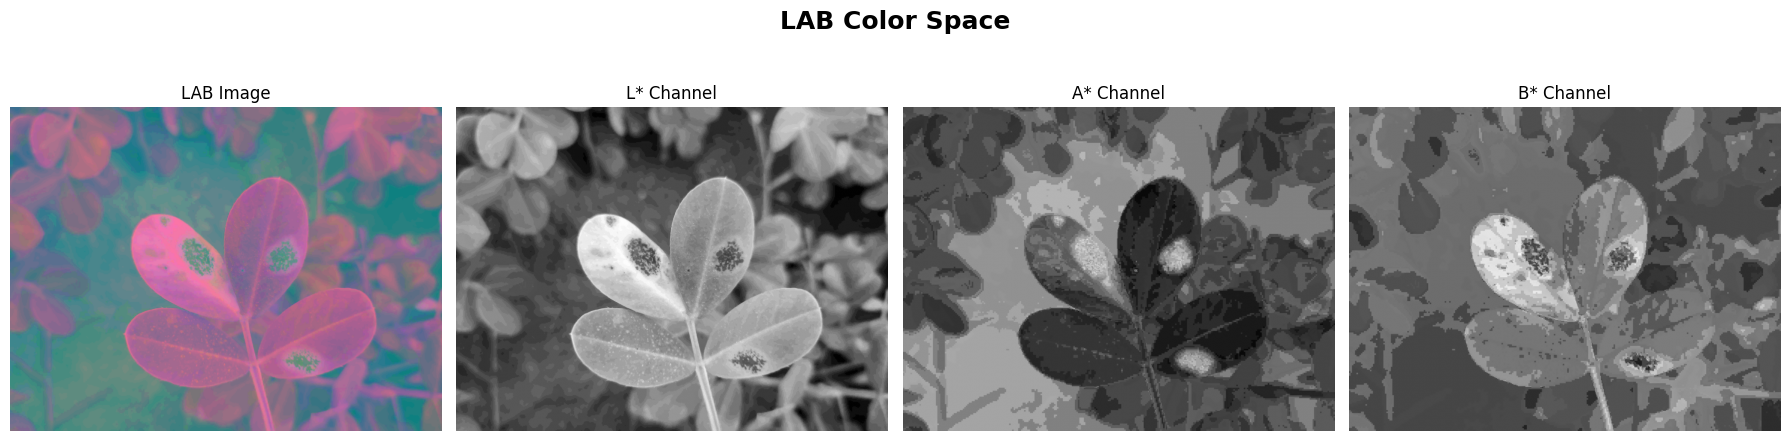

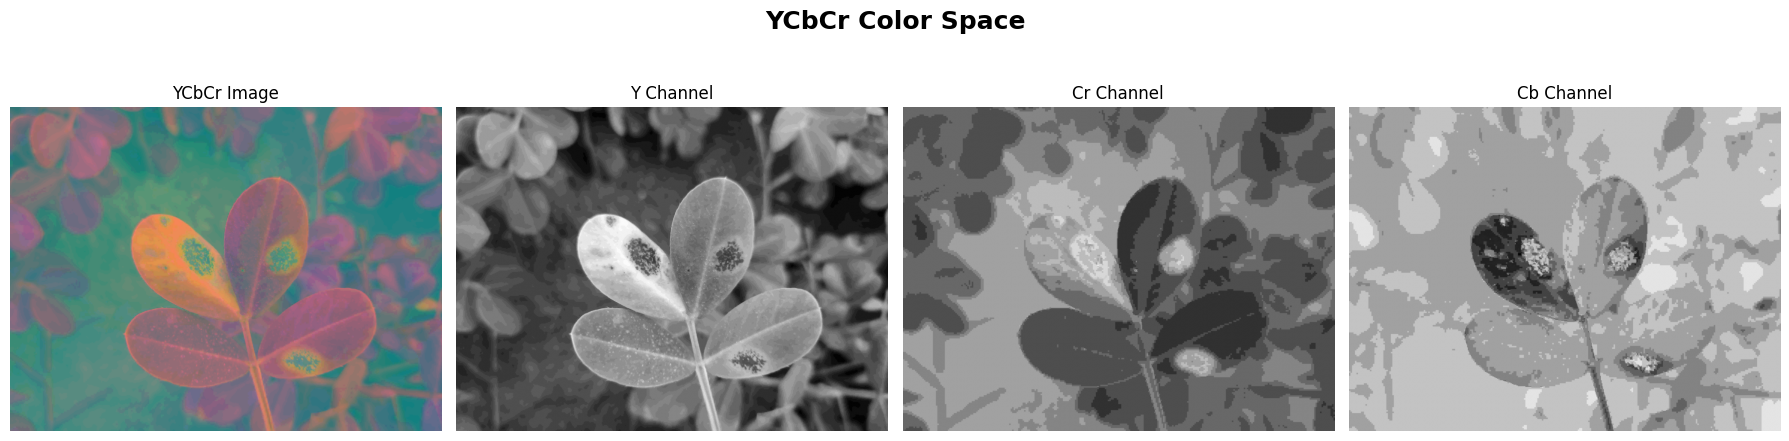

In [4]:
# ============================================================
# Image Color Space Visualization
# ============================================================
# This script:
# 1. Reads an image
# 2. Converts it into multiple color spaces
# 3. Displays each channel separately
#
# Supported Color Spaces:
# - RGB
# - LAB
# - YCbCr
#
# Author: Professional Image Processing Workflow
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Utility Function: Display Channels
# ------------------------------------------------------------
def display_channels(image, channels, channel_names, cmap_list, title):
    """
    Displays individual channels of a color space.

    Parameters:
    ----------
    image : ndarray
        Original converted image.
    channels : list
        List of separated image channels.
    channel_names : list
        Names of each channel.
    cmap_list : list
        Colormaps for visualization.
    title : str
        Title of the color space.
    """

    fig, axes = plt.subplots(1, len(channels) + 1, figsize=(18, 5))
    fig.suptitle(f"{title} Color Space", fontsize=18, fontweight='bold')

    # Show combined image
    axes[0].imshow(image)
    axes[0].set_title(f"{title} Image")
    axes[0].axis("off")

    # Show individual channels
    for i, (channel, name, cmap) in enumerate(zip(channels, channel_names, cmap_list)):
        axes[i + 1].imshow(channel, cmap=cmap)
        axes[i + 1].set_title(f"{name} Channel")
        axes[i + 1].axis("off")

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Read Image
# ------------------------------------------------------------
image_path = "/content/Alternaria Leaf Spot (2).jpg"   # Replace with your image path

# OpenCV reads image in BGR format
bgr_image = cv2.imread(image_path)

if bgr_image is None:
    raise FileNotFoundError(f"Image not found: {image_path}")

# Convert BGR to RGB for proper visualization
rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)


# ============================================================
# RGB COLOR SPACE
# ============================================================

R, G, B = cv2.split(rgb_image)

display_channels(
    image=rgb_image,
    channels=[R, G, B],
    channel_names=["Red", "Green", "Blue"],
    cmap_list=["Reds", "Greens", "Blues"],
    title="RGB"
)


# ============================================================
# LAB COLOR SPACE
# ============================================================

lab_image = cv2.cvtColor(rgb_image, cv2.COLOR_RGB2LAB)

L, A, B_lab = cv2.split(lab_image)

display_channels(
    image=lab_image,
    channels=[L, A, B_lab],
    channel_names=["L*", "A*", "B*"],
    cmap_list=["gray", "gray", "gray"],
    title="LAB"
)


# ============================================================
# YCbCr COLOR SPACE
# ============================================================

ycbcr_image = cv2.cvtColor(rgb_image, cv2.COLOR_RGB2YCrCb)

Y, Cr, Cb = cv2.split(ycbcr_image)

display_channels(
    image=ycbcr_image,
    channels=[Y, Cr, Cb],
    channel_names=["Y", "Cr", "Cb"],
    cmap_list=["gray", "gray", "gray"],
    title="YCbCr"
)

# Converting individual channels (LAB) into RGB

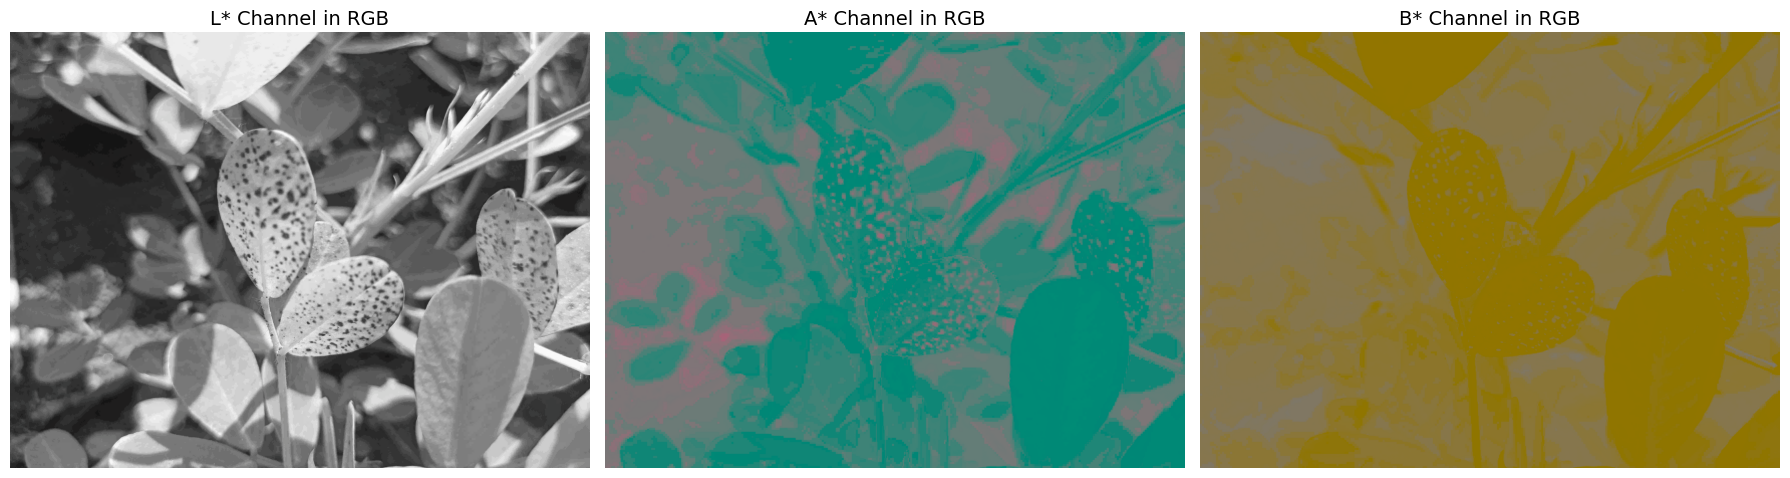

In [8]:
# ============================================================
# LAB CHANNELS VISUALIZED INDIVIDUALLY IN RGB
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Convert LAB Channel -> RGB Visualization
# ------------------------------------------------------------
def lab_channel_to_rgb(L=None, A=None, B=None):
    """
    Create an LAB image using one active channel
    and convert it back to RGB for visualization.
    """

    # Default neutral values
    lab = np.zeros((height, width, 3), dtype=np.uint8)

    # Neutral LAB values
    lab[:, :, 0] = 128   # L
    lab[:, :, 1] = 128   # A
    lab[:, :, 2] = 128   # B

    # Replace selected channel
    if L is not None:
        lab[:, :, 0] = L

    if A is not None:
        lab[:, :, 1] = A

    if B is not None:
        lab[:, :, 2] = B

    # Convert LAB -> RGB
    rgb = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

    return rgb


# ============================================================
# READ IMAGE
# ============================================================

image_path = "/content/Rust (13).jpg"

bgr_image = cv2.imread(image_path)

if bgr_image is None:
    raise FileNotFoundError("Image not found.")

rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)

height, width, _ = rgb_image.shape


# ============================================================
# RGB -> LAB
# ============================================================

lab_image = cv2.cvtColor(rgb_image, cv2.COLOR_RGB2LAB)

L, A, B_lab = cv2.split(lab_image)


# ============================================================
# INDIVIDUAL CHANNEL RGB VISUALIZATION
# ============================================================

# Only L active
L_rgb = lab_channel_to_rgb(L=L)

# Only A active
A_rgb = lab_channel_to_rgb(A=A)

# Only B active
B_rgb = lab_channel_to_rgb(B=B_lab)


# ============================================================
# DISPLAY RESULTS
# ============================================================

plt.figure(figsize=(18, 6))

# ------------------------------------------------------------
# L Channel
# ------------------------------------------------------------
plt.subplot(1, 3, 1)
plt.imshow(L_rgb)
plt.title("L* Channel in RGB", fontsize=14)
plt.axis("off")

# ------------------------------------------------------------
# A Channel
# ------------------------------------------------------------
plt.subplot(1, 3, 2)
plt.imshow(A_rgb)
plt.title("A* Channel in RGB", fontsize=14)
plt.axis("off")

# ------------------------------------------------------------
# B Channel
# ------------------------------------------------------------
plt.subplot(1, 3, 3)
plt.imshow(B_rgb)
plt.title("B* Channel in RGB", fontsize=14)
plt.axis("off")

plt.tight_layout()
plt.show()

# LAB CHANNEL VISUALIZATION INTO RGB

The main procedure used to enhance the visualization was:



*   Channel Normalization

*   Pseudocolor (False Color) Mapping

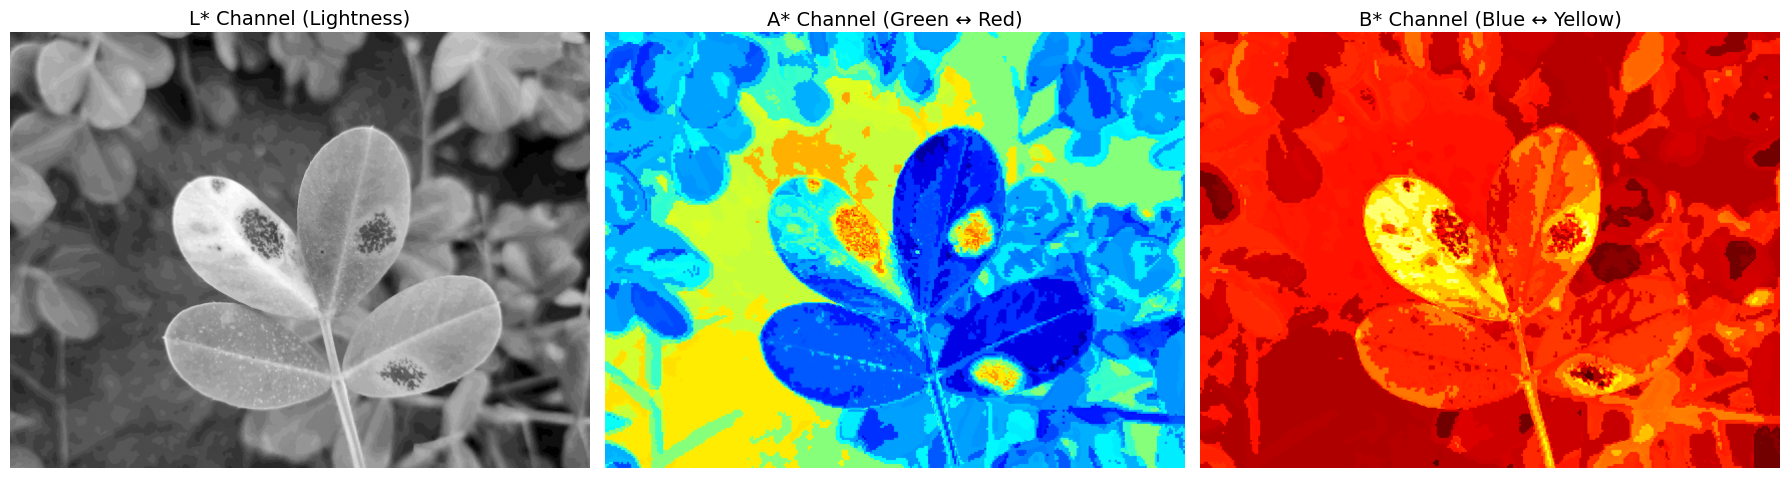

In [10]:
# ============================================================
# PROFESSIONAL LAB CHANNEL VISUALIZATION
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# READ IMAGE
# ============================================================

image_path = "/content/Alternaria Leaf Spot (2).jpg"

bgr_image = cv2.imread(image_path)

if bgr_image is None:
    raise FileNotFoundError("Image not found.")

rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)


# ============================================================
# RGB -> LAB
# ============================================================

lab_image = cv2.cvtColor(rgb_image, cv2.COLOR_RGB2LAB)

L, A, B = cv2.split(lab_image)


# ============================================================
# NORMALIZE CHANNELS
# ============================================================

L_norm = cv2.normalize(L, None, 0, 255, cv2.NORM_MINMAX)
A_norm = cv2.normalize(A, None, 0, 255, cv2.NORM_MINMAX)
B_norm = cv2.normalize(B, None, 0, 255, cv2.NORM_MINMAX)


# ============================================================
# APPLY COLORMAPS
# ============================================================

A_color = cv2.applyColorMap(A_norm, cv2.COLORMAP_JET)
B_color = cv2.applyColorMap(B_norm, cv2.COLORMAP_HOT)

# Convert BGR -> RGB for matplotlib
A_color = cv2.cvtColor(A_color, cv2.COLOR_BGR2RGB)
B_color = cv2.cvtColor(B_color, cv2.COLOR_BGR2RGB)


# ============================================================
# DISPLAY RESULTS
# ============================================================

plt.figure(figsize=(18, 6))

# ------------------------------------------------------------
# L CHANNEL
# ------------------------------------------------------------
plt.subplot(1, 3, 1)
plt.imshow(L_norm, cmap='gray')
plt.title("L* Channel (Lightness)", fontsize=14)
plt.axis("off")

# ------------------------------------------------------------
# A CHANNEL
# ------------------------------------------------------------
plt.subplot(1, 3, 2)
plt.imshow(A_color)
plt.title("A* Channel (Green ↔ Red)", fontsize=14)
plt.axis("off")

# ------------------------------------------------------------
# B CHANNEL
# ------------------------------------------------------------
plt.subplot(1, 3, 3)
plt.imshow(B_color)
plt.title("B* Channel (Blue ↔ Yellow)", fontsize=14)
plt.axis("off")

plt.tight_layout()
plt.show()